In [43]:
# zarr>=3 es obligatorio: los arreglos usan la especificación Zarr v3 (zarr.json, chunks en c/i/j/k/l)
!pip install -q --upgrade "zarr>=3" kaggle

In [44]:
import os, json, time, shutil, zipfile, tempfile
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("zarr", zarr.__version__, "| pandas", pd.__version__)

zarr 3.3.0 | pandas 2.2.3


In [45]:
# --- Autenticación de Kaggle -------------------------------------------------
# Kaggle tiene dos esquemas vigentes:
#   nuevo   -> un solo token KGAT_... en KAGGLE_API_TOKEN o ~/.kaggle/access_token
#   antiguo -> kaggle.json con username + key (KAGGLE_USERNAME / KAGGLE_KEY)
# En Colab: icono de llave (Secrets) -> crear el secreto y activar "Notebook access".

def setup_kaggle_auth():
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None

    def secret(name):
        v = os.environ.get(name)
        if v:
            return v
        if userdata is None:
            return None
        try:
            return userdata.get(name)
        except Exception:
            return None

    kdir = Path.home() / ".kaggle"
    kdir.mkdir(exist_ok=True)

    token = secret("KAGGLE_API_TOKEN")
    if token:
        os.environ["KAGGLE_API_TOKEN"] = token.strip()
        f = kdir / "access_token"
        f.write_text(token.strip())
        f.chmod(0o600)
        return "KAGGLE_API_TOKEN"

    raw = secret("KAGGLE_JSON")
    if raw:
        f = kdir / "kaggle.json"
        f.write_text(raw if isinstance(raw, str) else json.dumps(raw))
        f.chmod(0o600)
        return "kaggle.json"

    user, key = secret("KAGGLE_USERNAME"), secret("KAGGLE_KEY")
    if user and key:
        os.environ["KAGGLE_USERNAME"], os.environ["KAGGLE_KEY"] = user, key
        return "KAGGLE_USERNAME + KAGGLE_KEY"

    for f in (kdir / "access_token", kdir / "kaggle.json"):
        if f.exists():
            return f"archivo existente {f.name}"

    raise RuntimeError(
        "No hay credenciales. Crea en Colab (icono de llave) el secreto KAGGLE_API_TOKEN "
        "con tu token KGAT_..., o KAGGLE_USERNAME + KAGGLE_KEY si usas el esquema antiguo."
    )

print("Credenciales via:", setup_kaggle_auth())

Credenciales via: KAGGLE_API_TOKEN


In [46]:
COMPETITION        = "biohub-cell-tracking-during-development"
DATA_DIR           = Path("/content/data")      # cambiar a Path("data") fuera de Colab
TRAIN_DIR          = DATA_DIR / "train"

# El listado de `train` solo expone 2 embriones, así que subir N_EMBRYOS no agrega
# nada: la palanca real para agrandar la muestra es SAMPLES_PER_EMBRYO.
# Costo: cada .geff pesa ~170 KB, pero explorar y bajar cada uno son ~20 llamadas
# a la API. Con 15 por embrión son ~30 muestras y unos 10-15 min de descarga.
N_EMBRYOS          = 8      # embriones distintos a analizar (tope, no garantía)
SAMPLES_PER_EMBRYO = 15     # muestras (fields of view) por embrión
IMAGE_BUDGET_MB    = 250    # tope de disco para el volumen de imagen que se descarga

# Escala física del vóxel (Z, Y, X) en micras/píxel, documentada por los organizadores.
VOXEL_UM = np.array([1.625, 0.40625, 0.40625])

DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Destino:", DATA_DIR)

Destino: /content/data


In [47]:
from kaggle.api.kaggle_api_extended import KaggleApi
from kagglesdk.competitions.types.competition_api_service import ApiListDataTreeFilesRequest

api = KaggleApi()
api.authenticate()


def _is_fatal(err):
    # 403/404 no se reintenta: el archivo no existe o faltan permisos
    s = str(err)
    return "404" in s or "403" in s


def list_tree(path="", page_token=None, max_retries=6):
    # Lista una página de un directorio del dataset de la competencia
    for attempt in range(max_retries):
        try:
            with api.build_kaggle_client() as kaggle:
                req = ApiListDataTreeFilesRequest()
                req.competition_name = COMPETITION
                req.path = path
                if page_token:
                    req.page_token = page_token
                return kaggle.competitions.competition_api_client.list_data_tree_files(req)
        except Exception as e:
            if _is_fatal(e) or attempt == max_retries - 1:
                raise
            time.sleep(4 * (attempt + 1))


def list_tree_all(path=""):
    # Lista un directorio completo siguiendo la paginación
    dirs, files, token = [], [], None
    while True:
        r = list_tree(path, page_token=token)
        dirs += [d.name for d in getattr(r, "directories", [])]
        files += [f.name for f in getattr(r, "files", [])]
        token = getattr(r, "next_page_token", None)
        if not token:
            return dirs, files


def download_file(fname, max_retries=5):
    """Descarga un archivo suelto y lo deja en DATA_DIR/fname.

    ERROR ORIGINAL: se asumía que competition_download_file respeta la ruta
    completa. Dependiendo de la versión deja el archivo con otro nombre o
    comprimido, así que aquí se baja a un temporal y se coloca a mano."""
    target = DATA_DIR / fname
    if target.exists() and target.stat().st_size > 0:
        return target
    target.parent.mkdir(parents=True, exist_ok=True)

    for attempt in range(max_retries):
        tmp = Path(tempfile.mkdtemp())
        try:
            api.competition_download_file(COMPETITION, fname, path=str(tmp), quiet=True, force=True)
            got = [p for p in tmp.rglob("*") if p.is_file()]
            if not got:
                raise RuntimeError("descarga vacía")
            src = got[0]
            if src.suffix == ".zip" and not fname.endswith(".zip"):
                with zipfile.ZipFile(src) as z, open(target, "wb") as out:
                    with z.open(z.namelist()[0]) as member:
                        shutil.copyfileobj(member, out)
            else:
                shutil.move(str(src), str(target))
            return target
        except Exception as e:
            if _is_fatal(e) or attempt == max_retries - 1:
                raise
            time.sleep(4 * (attempt + 1))
        finally:
            shutil.rmtree(tmp, ignore_errors=True)


def download_many(fnames, workers=4, desc="Descargando"):
    ok, failed = [], []
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = {ex.submit(download_file, f): f for f in fnames}
        for fut in tqdm(as_completed(futs), total=len(futs), desc=desc):
            f = futs[fut]
            try:
                fut.result(); ok.append(f)
            except Exception as e:
                failed.append((f, str(e)[:120]))
    if failed:
        print(f"{len(failed)} archivos fallaron. Ejemplos:")
        for f, e in failed[:5]:
            print("  -", f, "->", e)
    return ok, failed

In [48]:
# --- Selección de muestras ---------------------------------------------------
# ERROR ORIGINAL: el bucle rompía al ver N_EMBRYOS embriones distintos, sin
# garantizar SAMPLES_PER_EMBRYO por embrión, y luego repetía el mismo cálculo dos
# veces. Además no verificaba que la muestra tuviera su .geff pareado.

zarr_stems, geff_stems = set(), set()
token, page = None, 0

while True:
    page += 1
    r = list_tree("train", page_token=token)
    for d in getattr(r, "directories", []):
        if d.name.endswith(".zarr"):
            zarr_stems.add(d.name[:-5])
        elif d.name.endswith(".geff"):
            geff_stems.add(d.name[:-5])

    paired = sorted(zarr_stems & geff_stems)
    by_embryo = defaultdict(list)
    for stem in paired:
        by_embryo[stem.split("_")[0]].append(stem)
    completos = [e for e, s in by_embryo.items() if len(s) >= SAMPLES_PER_EMBRYO]

    print(f"página {page}: {len(paired)} muestras pareadas, "
          f"{len(by_embryo)} embriones ({len(completos)} con >= {SAMPLES_PER_EMBRYO} muestras)")

    token = getattr(r, "next_page_token", None)
    if not token or len(completos) >= N_EMBRYOS:
        break
    time.sleep(1)

# Si no hay suficientes embriones completos, se completa con los que haya.
orden = sorted(by_embryo, key=lambda e: -len(by_embryo[e]))
SAMPLES = []
for embryo in orden[:N_EMBRYOS]:
    SAMPLES += sorted(by_embryo[embryo])[:SAMPLES_PER_EMBRYO]

print(f"\nEmbriones: {orden[:N_EMBRYOS]}")
print(f"Muestras seleccionadas ({len(SAMPLES)}):")
for s in SAMPLES:
    print("  -", s)

página 1: 10 muestras pareadas, 1 embriones (0 con >= 15 muestras)
página 2: 20 muestras pareadas, 1 embriones (1 con >= 15 muestras)
página 3: 30 muestras pareadas, 1 embriones (1 con >= 15 muestras)
página 4: 40 muestras pareadas, 1 embriones (1 con >= 15 muestras)
página 5: 50 muestras pareadas, 1 embriones (1 con >= 15 muestras)
página 6: 60 muestras pareadas, 1 embriones (1 con >= 15 muestras)
página 7: 70 muestras pareadas, 1 embriones (1 con >= 15 muestras)
página 8: 80 muestras pareadas, 2 embriones (1 con >= 15 muestras)
página 9: 90 muestras pareadas, 2 embriones (2 con >= 15 muestras)
página 10: 100 muestras pareadas, 2 embriones (2 con >= 15 muestras)
página 11: 110 muestras pareadas, 2 embriones (2 con >= 15 muestras)
página 12: 120 muestras pareadas, 2 embriones (2 con >= 15 muestras)
página 13: 130 muestras pareadas, 2 embriones (2 con >= 15 muestras)
página 14: 140 muestras pareadas, 2 embriones (2 con >= 15 muestras)
página 15: 150 muestras pareadas, 2 embriones (2 con

In [49]:
# --- Descarga de .geff sin listar el árbol de cada muestra --------------------
# El listado recursivo cuesta ~20 llamadas a la API por muestra y es lo que se
# colgaba. Aquí se explora UNA sola muestra para conocer la estructura, y para el
# resto se calculan los archivos exactos a partir de la metadata de cada arreglo.
import itertools

META_NAMES = {"zarr.json", ".zarray", ".zattrs", ".zgroup"}


def list_recursive(path):
    out, stack = [], [path]
    while stack:
        base = stack.pop()
        dirs, files = list_tree_all(base)
        out += [f"{base}/{f}" for f in files]
        stack += [f"{base}/{d}" for d in dirs]
    return out


def leer_meta(dir_local):
    # Metadata de un arreglo zarr; None si es un grupo o no existe
    p3, p2 = Path(dir_local) / "zarr.json", Path(dir_local) / ".zarray"
    if p3.exists():
        m = json.loads(p3.read_text())
        if m.get("node_type") == "group":
            return None
        return (tuple(m["shape"]), tuple(m["chunk_grid"]["configuration"]["chunk_shape"]),
                m.get("chunk_key_encoding", {"name": "default"}))
    if p2.exists():
        m = json.loads(p2.read_text())
        return (tuple(m["shape"]), tuple(m["chunks"]),
                {"name": "v2", "configuration": {"separator": "."}})
    return None


def chunks_de(dir_local, rel_dir):
    # Rutas de TODOS los chunks de un arreglo, derivadas de su metadata
    info = leer_meta(dir_local)
    if info is None:
        return []
    shape, ch, enc = info
    sep = enc.get("configuration", {}).get("separator",
                                           "." if enc.get("name") == "v2" else "/")
    pref = [] if enc.get("name") == "v2" else ["c"]
    grid = [range(-(-s // c)) for s, c in zip(shape, ch)]
    return [f"{rel_dir}/" + sep.join(pref + [str(i) for i in idx])
            for idx in itertools.product(*grid)]


def bajar_silencioso(files, workers=6):
    ok = 0
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = [ex.submit(download_file, f) for f in files]
        for fut in tqdm(as_completed(futs), total=len(futs), desc="Descargando"):
            try:
                fut.result(); ok += 1
            except Exception:
                pass
    return ok


# 1) Estructura: se explora solo la primera muestra
t0 = time.time()
plantilla = [p.split(f"{SAMPLES[0]}.geff/", 1)[1]
             for p in list_recursive(f"train/{SAMPLES[0]}.geff")]
meta_rel = sorted({p for p in plantilla if Path(p).name in META_NAMES})
print(f"Estructura del .geff: {len(plantilla)} archivos, {len(meta_rel)} de metadata "
      f"({time.time()-t0:.0f}s)")

# 2) Metadata de las 30 muestras (misma estructura) + niveles del .zarr
metas = [f"train/{s}.geff/{r}" for s in SAMPLES for r in meta_rel]
metas += [f"train/{s}.zarr/{lvl}/zarr.json" for s in SAMPLES for lvl in ("0", "1", "2")]
print(f"\nBajando {len(metas)} archivos de metadata...")
bajar_silencioso(metas)

# 3) Chunks de datos, calculados sin llamar a la API
datos = []
for s in SAMPLES:
    for r in meta_rel:
        rel_dir = str(Path(r).parent)
        if rel_dir == ".":
            continue
        datos += chunks_de(TRAIN_DIR / f"{s}.geff" / rel_dir, f"train/{s}.geff/{rel_dir}")
datos = sorted(set(datos))
print(f"\nBajando {len(datos)} archivos de datos...")
bajar_silencioso(datos)

geff_ok = sum(1 for s in SAMPLES if (TRAIN_DIR / f"{s}.geff" / "nodes" / "ids").exists())
print(f"\nListo en {time.time()-t0:.0f}s | muestras con grafo completo: {geff_ok}/{len(SAMPLES)}")

Estructura del .geff: 21 archivos, 15 de metadata (17s)

Bajando 540 archivos de metadata...


Descargando:   0%|          | 0/540 [00:00<?, ?it/s]


Bajando 180 archivos de datos...


Descargando:   0%|          | 0/180 [00:00<?, ?it/s]


Listo en 51s | muestras con grafo completo: 30/30


In [50]:
def zarr_json(path):
    """Lee la metadata de un arreglo zarr (v3: zarr.json, v2: .zarray)."""
    p3, p2 = Path(path) / "zarr.json", Path(path) / ".zarray"
    if p3.exists():
        m = json.loads(p3.read_text())
        if m.get("node_type") == "group":
            return None
        return {"shape": tuple(m["shape"]),
                "dtype": str(m.get("data_type", m.get("dtype"))),
                "chunks": tuple(m["chunk_grid"]["configuration"]["chunk_shape"]),
                "encoding": m.get("chunk_key_encoding", {"name": "default"}),
                "raw": m}
    if p2.exists():
        m = json.loads(p2.read_text())
        return {"shape": tuple(m["shape"]), "dtype": str(m["dtype"]),
                "chunks": tuple(m["chunks"]),
                "encoding": {"name": "v2", "configuration": {"separator": "."}},
                "raw": m}
    return None


def image_levels(stem):
    """Niveles de la pirámide multiescala disponibles localmente, con su metadata."""
    root = TRAIN_DIR / f"{stem}.zarr"
    out = {}
    if not root.exists():
        return out
    for d in sorted(root.iterdir()):
        if d.is_dir():
            m = zarr_json(d)
            if m:
                out[d.name] = m
    return out


def read_geff(stem):
    """Lee un grafo .geff -> (atributos, ids de nodo, props dict, aristas)."""
    g = TRAIN_DIR / f"{stem}.geff"
    attrs = {}
    try:
        attrs = dict(zarr.open_group(str(g), mode="r").attrs)
    except Exception:
        pass

    node_ids = np.asarray(zarr.open(str(g / "nodes" / "ids"), mode="r")[:])
    props = {}
    for name in ("t", "z", "y", "x"):
        p = g / "nodes" / "props" / name / "values"
        props[name] = (np.asarray(zarr.open(str(p), mode="r")[:]).astype(float)
                       if p.exists() else np.full(node_ids.shape[0], np.nan))

    ep = g / "edges" / "ids"
    edges = np.asarray(zarr.open(str(ep), mode="r")[:]) if ep.exists() else np.zeros((0, 2), int)
    return attrs, node_ids, props, edges


def find_key(d, key):
    """Busca una llave recursivamente en atributos anidados."""
    if not isinstance(d, dict):
        return None
    if key in d:
        return d[key]
    for v in d.values():
        r = find_key(v, key)
        if r is not None:
            return r
    return None

In [51]:
# --- Diagnóstico y reparación de descargas incompletas -----------------------
# bajar_silencioso ignora los fallos, así que puede quedar un directorio creado
# pero vacío. Aquí se detecta qué falta y se reintenta mostrando los errores.

def tiene_meta(d):
    return (Path(d) / "zarr.json").exists() or (Path(d) / ".zarray").exists()


ARRAYS_REQ = ["nodes/ids", "edges/ids"] + [f"nodes/props/{n}/values" for n in ("t", "z", "y", "x")]

faltantes = {}
for s in SAMPLES:
    base = TRAIN_DIR / f"{s}.geff"
    falta = [r for r in ARRAYS_REQ if not tiene_meta(base / r)]
    if falta:
        faltantes[s] = falta

print(f"Muestras con arreglos incompletos: {len(faltantes)}/{len(SAMPLES)}")
for s, f in list(faltantes.items())[:10]:
    print(f"  {s}: falta {f}")

# Reintento visible de la metadata que falta
if faltantes:
    pendientes = [f"train/{s}.geff/{r}/zarr.json" for s, rs in faltantes.items() for r in rs]
    print(f"\nReintentando {len(pendientes)} archivos de metadata...")
    ok, fallidos = download_many(pendientes, workers=4, desc="Metadata faltante")

    # Y los chunks de los arreglos que sí se recuperaron
    nuevos = []
    for s, rs in faltantes.items():
        for r in rs:
            nuevos += chunks_de(TRAIN_DIR / f"{s}.geff" / r, f"train/{s}.geff/{r}")
    if nuevos:
        print(f"\nBajando {len(nuevos)} chunks de datos...")
        bajar_silencioso(nuevos)

# Verificación final
INCOMPLETAS = [s for s in SAMPLES
               if not all(tiene_meta(TRAIN_DIR / f"{s}.geff" / r) for r in ARRAYS_REQ)]
SAMPLES_OK = [s for s in SAMPLES if s not in INCOMPLETAS]
print(f"\nMuestras utilizables: {len(SAMPLES_OK)}/{len(SAMPLES)}")
if INCOMPLETAS:
    print("Se excluyen del análisis:", INCOMPLETAS)

Muestras con arreglos incompletos: 0/30

Muestras utilizables: 30/30


In [52]:
# --- read_geff tolerante -----------------------------------------------------
# Antes comprobaba que el directorio existiera; ahora exige que tenga metadata,
# porque una descarga fallida deja la carpeta creada pero vacía.

def read_geff(stem):
    g = TRAIN_DIR / f"{stem}.geff"
    attrs = {}
    try:
        attrs = dict(zarr.open_group(str(g), mode="r").attrs)
    except Exception:
        pass

    node_ids = np.asarray(zarr.open(str(g / "nodes" / "ids"), mode="r")[:])
    props = {}
    for name in ("t", "z", "y", "x"):
        p = g / "nodes" / "props" / name / "values"
        if tiene_meta(p):
            props[name] = np.asarray(zarr.open(str(p), mode="r")[:]).astype(float)
        else:
            print(f"AVISO: {stem} no tiene la propiedad '{name}'")
            props[name] = np.full(node_ids.shape[0], np.nan)

    ep = g / "edges" / "ids"
    edges = np.asarray(zarr.open(str(ep), mode="r")[:]) if tiene_meta(ep) else np.zeros((0, 2), int)
    return attrs, node_ids, props, edges


# A partir de aquí el análisis usa solo las muestras completas
SAMPLES = SAMPLES_OK
print(f"SAMPLES = {len(SAMPLES)} muestras completas")

SAMPLES = 30 muestras completas


In [53]:
# --- Recuperación paciente: secuencial, con reintento de los 404 -------------
import random

def bajar_terco(fname, intentos=6):
    target = DATA_DIR / fname
    if target.exists() and target.stat().st_size > 0:
        return True
    target.parent.mkdir(parents=True, exist_ok=True)
    for k in range(intentos):
        tmp = Path(tempfile.mkdtemp())
        try:
            api.competition_download_file(COMPETITION, fname, path=str(tmp), quiet=True, force=True)
            got = [p for p in tmp.rglob("*") if p.is_file()]
            if got:
                shutil.move(str(got[0]), str(target))
                return True
        except Exception:
            pass
        finally:
            shutil.rmtree(tmp, ignore_errors=True)
        time.sleep(min(30, 3 * 2 ** k) + random.uniform(0, 2))   # 3, 6, 12, 24, 30, 30 s
    return False


pendientes = sorted(set(restantes))
print(f"Pendientes: {len(pendientes)} | estimado: {len(pendientes) * 4 / 60:.0f}-{len(pendientes) * 15 / 60:.0f} min\n")

recuperados, sin_suerte = 0, []
for k, f in enumerate(tqdm(pendientes, desc="Recuperando"), 1):
    if bajar_terco(f):
        recuperados += 1
    else:
        sin_suerte.append(f)
    time.sleep(1.5)                       # espaciado entre archivos
    if k % 20 == 0:
        print(f"  {k}/{len(pendientes)}: {recuperados} ok, {len(sin_suerte)} sin suerte", flush=True)

print(f"\nRecuperados: {recuperados} | siguen faltando: {len(sin_suerte)}")

Pendientes: 102 | estimado: 7-26 min



Recuperando:   0%|          | 0/102 [00:00<?, ?it/s]

  20/102: 20 ok, 0 sin suerte
  40/102: 40 ok, 0 sin suerte
  60/102: 60 ok, 0 sin suerte
  80/102: 80 ok, 0 sin suerte
  100/102: 100 ok, 0 sin suerte

Recuperados: 102 | siguen faltando: 0


In [54]:
# --- Filtro estricto: solo muestras con TODOS los chunks y datos coherentes ---
def muestra_valida(s):
    for r in ARRAYS_REQ:
        rutas = chunks_de(TRAIN_DIR / f"{s}.geff" / r, f"train/{s}.geff/{r}")
        if not rutas or any(not (DATA_DIR / x).exists() for x in rutas):
            return False, f"faltan chunks en {r}"
    try:
        _, ids, props, edges = read_geff(s)
        if len(np.unique(ids)) < len(ids) * 0.9:
            return False, "ids repetidos (datos en cero)"
        if np.nanmax(props["t"]) == np.nanmin(props["t"]):
            return False, "t constante"
    except Exception as e:
        return False, str(e)[:50]
    return True, "ok"


validas, descartadas = [], {}
for s in SAMPLES_OK if "SAMPLES_OK" in dir() else SAMPLES:
    ok, razon = muestra_valida(s)
    (validas.append(s) if ok else descartadas.update({s: razon}))

print(f"Muestras válidas: {len(validas)}")
for s, r in list(descartadas.items())[:10]:
    print(f"  descartada {s}: {r}")

SAMPLES = validas
assert SAMPLES, "No quedó ninguna muestra completa."
print(f"\nSAMPLES = {len(SAMPLES)} muestras | embriones: "
      f"{sorted({s.split('_')[0] for s in SAMPLES})}")

Muestras válidas: 30

SAMPLES = 30 muestras | embriones: ['44b6', '6bba']


In [55]:
# --- Construcción de las tres tablas ----------------------------------------
node_rows, edge_rows, sample_rows = [], [], []

for stem in tqdm(SAMPLES, desc="Construyendo tablas"):
    embryo = stem.split("_")[0]
    attrs, ids, props, edges = read_geff(stem)

    n = len(ids)
    idx = {int(v): i for i, v in enumerate(ids)}          # id de nodo -> posición
    indeg, outdeg = np.zeros(n, int), np.zeros(n, int)

    e_src = np.array([idx[int(a)] for a, b in edges if int(a) in idx and int(b) in idx], int)
    e_dst = np.array([idx[int(b)] for a, b in edges if int(a) in idx and int(b) in idx], int)
    for i in e_src:
        outdeg[i] += 1
    for i in e_dst:
        indeg[i] += 1

    nodes = pd.DataFrame({
        "sample": stem, "embryo_id": embryo, "node_id": ids,
        "t": props["t"], "z": props["z"], "y": props["y"], "x": props["x"],
        "in_degree": indeg, "out_degree": outdeg,
    })
    nodes["z_um"] = nodes["z"] * VOXEL_UM[0]
    nodes["y_um"] = nodes["y"] * VOXEL_UM[1]
    nodes["x_um"] = nodes["x"] * VOXEL_UM[2]
    nodes["es_division"] = nodes["out_degree"] >= 2
    nodes["tipo_temporal"] = np.select(
        [(nodes.in_degree == 0) & (nodes.out_degree == 0),
         nodes.in_degree == 0,
         nodes.out_degree == 0],
        ["aislado", "inicio", "fin"], default="intermedio")
    node_rows.append(nodes)

    if len(e_src):
        a, b = nodes.iloc[e_src].reset_index(drop=True), nodes.iloc[e_dst].reset_index(drop=True)
        d = np.stack([(b.z_um - a.z_um), (b.y_um - a.y_um), (b.x_um - a.x_um)], 1)
        edge_rows.append(pd.DataFrame({
            "sample": stem, "embryo_id": embryo,
            "t_origen": a.t.values, "dt": (b.t - a.t).values,
            "dz_um": d[:, 0], "dy_um": d[:, 1], "dx_um": d[:, 2],
            "dist_um": np.linalg.norm(d, axis=1),
            "out_degree_origen": a.out_degree.values,
        }))

    lvls = image_levels(stem)
    lvl0 = lvls.get("0") or (list(lvls.values())[0] if lvls else None)
    shape0 = lvl0["shape"] if lvl0 else (np.nan,) * 4

    sample_rows.append({
        "sample": stem, "embryo_id": embryo, "field_of_view": "_".join(stem.split("_")[1:]),
        "T": shape0[0], "Z": shape0[1], "Y": shape0[2], "X": shape0[3],
        "dtype": lvl0["dtype"] if lvl0 else None,
        "n_niveles_piramide": len(lvls),
        "n_nodos": n, "n_aristas": len(e_src),
        "t_min": np.nanmin(props["t"]) if n else np.nan,
        "t_max": np.nanmax(props["t"]) if n else np.nan,
        "n_t_anotados": len(np.unique(props["t"])) if n else 0,
        "n_divisiones": int((outdeg >= 2).sum()),
        "estimated_number_of_nodes": find_key(attrs, "estimated_number_of_nodes"),
    })

EDGE_COLS = ["sample", "embryo_id", "t_origen", "dt", "dz_um", "dy_um", "dx_um",
             "dist_um", "out_degree_origen"]
df_nodes = pd.concat(node_rows, ignore_index=True)
df_edges = (pd.concat(edge_rows, ignore_index=True) if edge_rows
            else pd.DataFrame(columns=EDGE_COLS).astype(float))
df_samples = pd.DataFrame(sample_rows)

# Variables derivadas a nivel de muestra
df_samples["cobertura_temporal"] = df_samples["n_t_anotados"] / df_samples["T"]
df_samples["nodos_por_t"] = df_samples["n_nodos"] / df_samples["n_t_anotados"]
df_samples["aristas_por_nodo"] = df_samples["n_aristas"] / df_samples["n_nodos"]
df_samples["tasa_division"] = df_samples["n_divisiones"] / df_samples["n_nodos"]

print(f"df_samples: {df_samples.shape} | df_nodes: {df_nodes.shape} | df_edges: {df_edges.shape}")
df_samples

Construyendo tablas:   0%|          | 0/30 [00:00<?, ?it/s]

df_samples: (30, 20) | df_nodes: (15934, 14) | df_edges: (15369, 9)


,sample,embryo_id,field_of_view,T,Z,Y,X,dtype,n_niveles_piramide,n_nodos,n_aristas,t_min,t_max,n_t_anotados,n_divisiones,estimated_number_of_nodes,cobertura_temporal,nodos_por_t,aristas_por_nodo,tasa_division
0,6bba_05b6850b,6bba,05b6850b,100,64,256,256,uint16,1,861,845,0.0,99.0,100,0,6362,1.00,8.610000,0.981417,0.000000
1,6bba_05db0fb1,6bba,05db0fb1,100,64,256,256,uint16,1,1229,1183,0.0,99.0,100,3,69800,1.00,12.290000,0.962571,0.002441
2,6bba_062c8d37,6bba,062c8d37,100,64,256,256,uint16,1,930,898,0.0,99.0,99,1,6030,0.99,9.393939,0.965591,0.001075
3,6bba_07477033,6bba,07477033,100,64,256,256,uint16,1,613,602,0.0,99.0,100,0,4836,1.00,6.130000,0.982055,0.000000
4,6bba_07e24132,6bba,07e24132,100,64,256,256,uint16,1,359,345,0.0,99.0,100,2,21485,1.00,3.590000,0.961003,0.005571
5,6bba_085bf656,6bba,085bf656,100,64,256,256,uint16,1,1198,1168,0.0,99.0,100,1,8463,1.00,11.980000,0.974958,0.000835
6,6bba_09961292,6bba,09961292,100,64,256,256,uint16,1,1950,1871,0.0,99.0,100,4,31117,1.00,19.500000,0.959487,0.002051
7,6bba_0c7fa718,6bba,0c7fa718,100,64,256,256,uint16,1,704,659,0.0,99.0,94,0,13650,0.94,7.489362,0.936080,0.000000
8,6bba_0e7c0d07,6bba,0e7c0d07,100,64,256,256,uint16,1,209,198,0.0,85.0,84,1,22467,0.84,2.488095,0.947368,0.004785
9,6bba_12665c0e,6bba,12665c0e,100,64,256,256,uint16,1,1036,998,0.0,99.0,100,3,8314,1.00,10.360000,0.963320,0.002896


In [56]:
for nombre, d in [("df_samples", df_samples), ("df_nodes", df_nodes), ("df_edges", df_edges)]:
    print(f"\n=== {nombre}: {d.shape[0]} observaciones x {d.shape[1]} variables ===")
    print(pd.DataFrame({
        "tipo": d.dtypes.astype(str),
        "n_unicos": d.nunique(),
        "n_faltantes": d.isna().sum(),
        "% faltante": (d.isna().mean() * 100).round(2),
    }))


=== df_samples: 30 observaciones x 20 variables ===
                              tipo  n_unicos  n_faltantes  % faltante
sample                      object        30            0         0.0
embryo_id                   object         2            0         0.0
field_of_view               object        30            0         0.0
T                            int64         1            0         0.0
Z                            int64         1            0         0.0
Y                            int64         1            0         0.0
X                            int64         1            0         0.0
dtype                       object         1            0         0.0
n_niveles_piramide           int64         1            0         0.0
n_nodos                      int64        30            0         0.0
n_aristas                    int64        29            0         0.0
t_min                      float64         5            0         0.0
t_max                      float64   

In [57]:
# Clasificación conceptual de las variables (para el informe)
tipos = pd.DataFrame([
    ("sample",        "categórica nominal", "identificador de la muestra (embrión + field of view)"),
    ("embryo_id",     "categórica nominal", "embrión de origen; permite comparar entre individuos"),
    ("t",             "numérica discreta",  "índice de instante temporal (frame)"),
    ("z, y, x",       "numérica continua",  "coordenada del centroide en píxeles del nivel 0"),
    ("z_um, y_um, x_um", "numérica continua", "misma coordenada en micras (escala física)"),
    ("in_degree",     "numérica discreta",  "aristas entrantes: 0 = aparición o inicio de la anotación"),
    ("out_degree",    "numérica discreta",  "aristas salientes: 2 = división celular"),
    ("es_division",   "categórica binaria", "el nodo se divide en el siguiente frame"),
    ("tipo_temporal", "categórica nominal", "inicio / intermedio / fin / aislado dentro de la trayectoria"),
    ("dt",            "numérica discreta",  "salto temporal del enlace (frames)"),
    ("dist_um",       "numérica continua",  "desplazamiento 3D del enlace en micras"),
], columns=["variable", "tipo", "descripción"])
tipos

,variable,tipo,descripción
0,sample,categórica nominal,identificador de la muestra (embrión + field o...
1,embryo_id,categórica nominal,embrión de origen; permite comparar entre indi...
2,t,numérica discreta,índice de instante temporal (frame)
3,"z, y, x",numérica continua,coordenada del centroide en píxeles del nivel 0
4,"z_um, y_um, x_um",numérica continua,misma coordenada en micras (escala física)
5,in_degree,numérica discreta,aristas entrantes: 0 = aparición o inicio de l...
6,out_degree,numérica discreta,aristas salientes: 2 = división celular
7,es_division,categórica binaria,el nodo se divide en el siguiente frame
8,tipo_temporal,categórica nominal,inicio / intermedio / fin / aislado dentro de ...
9,dt,numérica discreta,salto temporal del enlace (frames)


In [58]:
# --- Validaciones de integridad ---------------------------------------------
print("Nodos duplicados (sample, node_id):", df_nodes.duplicated(["sample", "node_id"]).sum())
print("Aristas con dt <= 0:", int((df_edges["dt"] <= 0).sum()))
print("Distribución de dt:\n", df_edges["dt"].value_counts().head())

print("\nCoordenadas fuera del volumen de imagen:")
lim = df_samples.set_index("sample")[["Z", "Y", "X"]]
for s, g in df_nodes.groupby("sample"):
    if s in lim.index and lim.loc[s].notna().all():
        fuera = ((g.z < 0) | (g.z >= lim.loc[s, "Z"]) |
                 (g.y < 0) | (g.y >= lim.loc[s, "Y"]) |
                 (g.x < 0) | (g.x >= lim.loc[s, "X"])).sum()
        print(f"  {s}: {fuera} de {len(g)}")

print("\nFaltantes por columna en df_nodes:")
print(df_nodes.isna().sum()[lambda s: s > 0] if df_nodes.isna().any().any() else "  ninguno")

Nodos duplicados (sample, node_id): 0
Aristas con dt <= 0: 0
Distribución de dt:
 dt
1.0    15369
Name: count, dtype: int64

Coordenadas fuera del volumen de imagen:
  44b6_0113de3b: 0 de 52
  44b6_0b24845f: 0 de 51
  44b6_0c582fdc: 0 de 71
  44b6_0db75fae: 0 de 157
  44b6_12dfb391: 0 de 788
  44b6_144b256d: 0 de 121
  44b6_1574802b: 0 de 155
  44b6_18ced818: 0 de 100
  44b6_1d530831: 0 de 276
  44b6_24264f12: 0 de 230
  44b6_267148e4: 0 de 280
  44b6_2a2eff9f: 0 de 214
  44b6_2f31fc2f: 0 de 89
  44b6_33b596bf: 0 de 50
  44b6_341df25f: 0 de 216
  6bba_05b6850b: 0 de 861
  6bba_05db0fb1: 0 de 1229
  6bba_062c8d37: 0 de 930
  6bba_07477033: 0 de 613
  6bba_07e24132: 0 de 359
  6bba_085bf656: 0 de 1198
  6bba_09961292: 0 de 1950
  6bba_0c7fa718: 0 de 704
  6bba_0e7c0d07: 0 de 209
  6bba_12665c0e: 0 de 1036
  6bba_13f19531: 0 de 737
  6bba_15403b9a: 0 de 758
  6bba_1d0d8384: 0 de 1438
  6bba_1ebfb80d: 0 de 745
  6bba_1f58c2f6: 0 de 317

Faltantes por columna en df_nodes:
  ninguno


In [59]:
print("=== Nivel muestra ===")
cols_s = ["T", "Z", "Y", "X", "n_nodos", "n_aristas", "n_t_anotados", "cobertura_temporal",
          "nodos_por_t", "aristas_por_nodo", "tasa_division"]
cols_s += [c for c in ["densidad_anotacion"] if c in df_samples]
display(df_samples[cols_s].describe().T.round(3))

print("\n=== Nivel nodo ===")
display(df_nodes[["t", "z_um", "y_um", "x_um", "in_degree", "out_degree"]].describe().T.round(3))

print("\n=== Nivel arista ===")
display(df_edges[["dt", "dz_um", "dy_um", "dx_um", "dist_um"]].describe().T.round(3))

=== Nivel muestra ===


,count,mean,std,min,25%,50%,75%,max
T,30.0,100.000,0.000,100.000,100.000,100.000,100.000,100.000
Z,30.0,64.000,0.000,64.000,64.000,64.000,64.000,64.000
Y,30.0,256.000,0.000,256.000,256.000,256.000,256.000,256.000
X,30.0,256.000,0.000,256.000,256.000,256.000,256.000,256.000
n_nodos,30.0,531.133,486.528,50.000,155.500,298.500,780.500,1950.000
n_aristas,30.0,512.300,467.301,49.000,151.500,288.000,762.000,1871.000
n_t_anotados,30.0,90.967,16.986,40.000,90.250,100.000,100.000,100.000
cobertura_temporal,30.0,0.910,0.170,0.400,0.902,1.000,1.000,1.000
nodos_por_t,30.0,5.446,4.772,1.000,1.665,3.001,7.805,19.500
aristas_por_nodo,30.0,0.968,0.015,0.936,0.961,0.964,0.981,0.990



=== Nivel nodo ===


,count,mean,std,min,25%,50%,75%,max
t,15934.0,46.144,27.804,0.0,22.000,45.000,69.000,99.000
z_um,15934.0,47.960,28.751,0.0,22.750,47.125,69.875,102.375
y_um,15934.0,53.838,27.874,0.0,32.500,54.031,77.594,103.594
x_um,15934.0,49.824,28.273,0.0,25.594,49.969,72.719,103.594
in_degree,15934.0,0.965,0.185,0.0,1.000,1.000,1.000,1.000
out_degree,15934.0,0.965,0.192,0.0,1.000,1.000,1.000,2.000



=== Nivel arista ===


,count,mean,std,min,25%,50%,75%,max
dt,15369.0,1.000,0.000,1.000,1.000,1.000,1.000,1.000
dz_um,15369.0,-0.343,1.598,-11.375,-1.625,0.000,0.000,9.750
dy_um,15369.0,0.211,1.437,-10.156,-0.406,0.000,0.812,13.000
dx_um,15369.0,-0.128,1.712,-13.812,-0.812,0.000,0.812,8.938
dist_um,15369.0,2.171,1.736,0.000,0.908,1.862,2.873,17.967


In [60]:
# Cuantiles del desplazamiento: acotan el radio de búsqueda de un algoritmo de enlace
q = df_edges.loc[df_edges.dt == 1, "dist_um"].quantile([.5, .75, .9, .95, .99, 1.0]).round(2)
print("Desplazamiento entre frames consecutivos (micras):")
print(q.to_string())
print(f"\nUn radio de busqueda de {q[0.99]:.1f} um cubriria el 99% de los enlaces reales.")

Desplazamiento entre frames consecutivos (micras):
0.50     1.86
0.75     2.87
0.90     4.18
0.95     5.40
0.99     8.35
1.00    17.97

Un radio de busqueda de 8.3 um cubriria el 99% de los enlaces reales.


In [61]:
def tabla_frecuencia(serie, nombre):
    t = pd.concat([serie.value_counts().rename("frecuencia"),
                   (serie.value_counts(normalize=True) * 100).round(2).rename("%")], axis=1)
    print(f"\n--- {nombre} ---")
    display(t)
    return t

tabla_frecuencia(df_samples["embryo_id"], "Muestras por embrión")
tabla_frecuencia(df_nodes["embryo_id"], "Nodos anotados por embrión")
tabla_frecuencia(df_nodes["tipo_temporal"], "Tipo de nodo dentro de la trayectoria")
tabla_frecuencia(df_nodes["out_degree"], "Grado de salida (2 = división)")
tabla_frecuencia(df_nodes["in_degree"], "Grado de entrada")
None


--- Muestras por embrión ---


,frecuencia,%
embryo_id,,
6bba,15,50.0
44b6,15,50.0



--- Nodos anotados por embrión ---


,frecuencia,%
embryo_id,,
6bba,13084,82.11
44b6,2850,17.89



--- Tipo de nodo dentro de la trayectoria ---


,frecuencia,%
tipo_temporal,,
intermedio,14784,92.78
fin,585,3.67
inicio,565,3.55



--- Grado de salida (2 = división) ---


,frecuencia,%
out_degree,,
1,15329,96.20
0,585,3.67
2,20,0.13



--- Grado de entrada ---


,frecuencia,%
in_degree,,
1,15369,96.45
0,565,3.55


tipo_temporal,fin,inicio,intermedio
embryo_id,,,
44b6,2.39,2.25,95.37
6bba,3.95,3.83,92.22


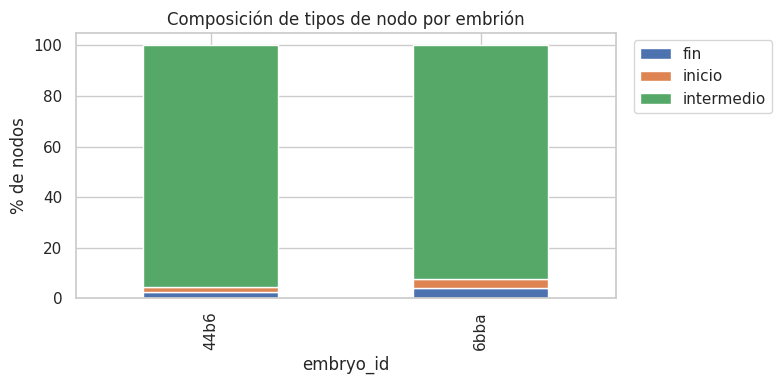

In [62]:
# Tabla cruzada: composición de tipos de nodo por embrión (proporciones por fila)
cruce = pd.crosstab(df_nodes["embryo_id"], df_nodes["tipo_temporal"], normalize="index") * 100
display(cruce.round(2))

cruce.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.ylabel("% de nodos"); plt.title("Composición de tipos de nodo por embrión")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); plt.tight_layout(); plt.show()

       sample embryo_id  n_nodos  estimated_number_of_nodes  densidad_anotacion  cobertura_temporal
6bba_05b6850b      6bba      861                       6362               13.53                1.00
6bba_05db0fb1      6bba     1229                      69800                1.76                1.00
6bba_062c8d37      6bba      930                       6030               15.42                0.99
6bba_07477033      6bba      613                       4836               12.68                1.00
6bba_07e24132      6bba      359                      21485                1.67                1.00
6bba_085bf656      6bba     1198                       8463               14.16                1.00
6bba_09961292      6bba     1950                      31117                6.27                1.00
6bba_0c7fa718      6bba      704                      13650                5.16                0.94
6bba_0e7c0d07      6bba      209                      22467                0.93                0.84


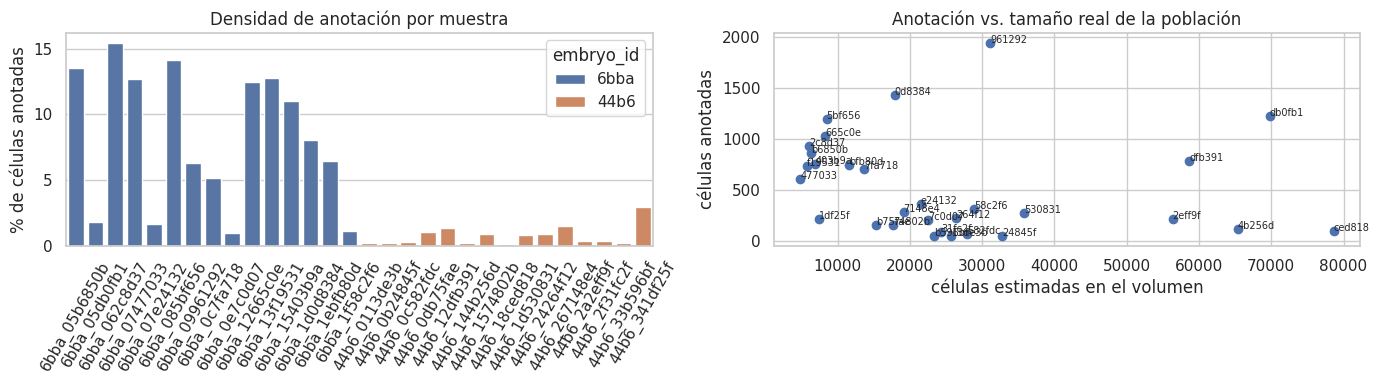

In [63]:
# --- Densidad de anotación: qué fracción de las células está etiquetada ------
df_samples["densidad_anotacion"] = (df_samples["n_nodos"] /
                                    df_samples["estimated_number_of_nodes"] * 100)

print(df_samples[["sample", "embryo_id", "n_nodos", "estimated_number_of_nodes",
                  "densidad_anotacion", "cobertura_temporal"]].round(2).to_string(index=False))

glob = df_samples.n_nodos.sum() / df_samples.estimated_number_of_nodes.sum() * 100
print(f"\nDensidad global: {glob:.2f}% de las células estimadas están anotadas")
print(f"Rango entre muestras: {df_samples.densidad_anotacion.min():.2f}% – "
      f"{df_samples.densidad_anotacion.max():.2f}% "
      f"(factor {df_samples.densidad_anotacion.max()/df_samples.densidad_anotacion.min():.0f}x)")
print("\nPor embrión:")
print(df_samples.groupby("embryo_id")["densidad_anotacion"].describe()[["count","mean","min","max"]].round(2))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=df_samples, x="sample", y="densidad_anotacion", hue="embryo_id", ax=ax[0])
ax[0].set_title("Densidad de anotación por muestra"); ax[0].set_ylabel("% de células anotadas")
ax[0].tick_params(axis="x", rotation=60); ax[0].set_xlabel("")

ax[1].scatter(df_samples.estimated_number_of_nodes, df_samples.n_nodos)
for _, r in df_samples.iterrows():
    ax[1].annotate(r["sample"][-6:], (r.estimated_number_of_nodes, r.n_nodos), fontsize=7)
ax[1].set_xlabel("células estimadas en el volumen"); ax[1].set_ylabel("células anotadas")
ax[1].set_title("Anotación vs. tamaño real de la población")
plt.tight_layout(); plt.show()

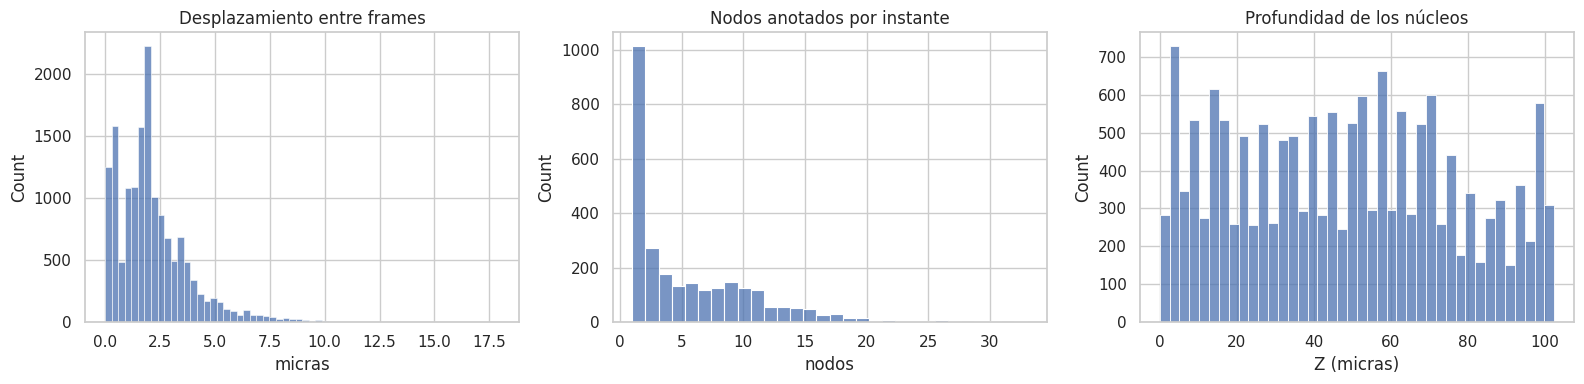

In [64]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df_edges.loc[df_edges.dt == 1, "dist_um"], bins=60, ax=ax[0])
ax[0].set_title("Desplazamiento entre frames"); ax[0].set_xlabel("micras")

nodos_t = df_nodes.groupby(["sample", "t"]).size().rename("n").reset_index()
sns.histplot(nodos_t["n"], bins=30, ax=ax[1])
ax[1].set_title("Nodos anotados por instante"); ax[1].set_xlabel("nodos")

sns.histplot(df_nodes["z_um"], bins=40, ax=ax[2])
ax[2].set_title("Profundidad de los núcleos"); ax[2].set_xlabel("Z (micras)")

plt.tight_layout(); plt.show()

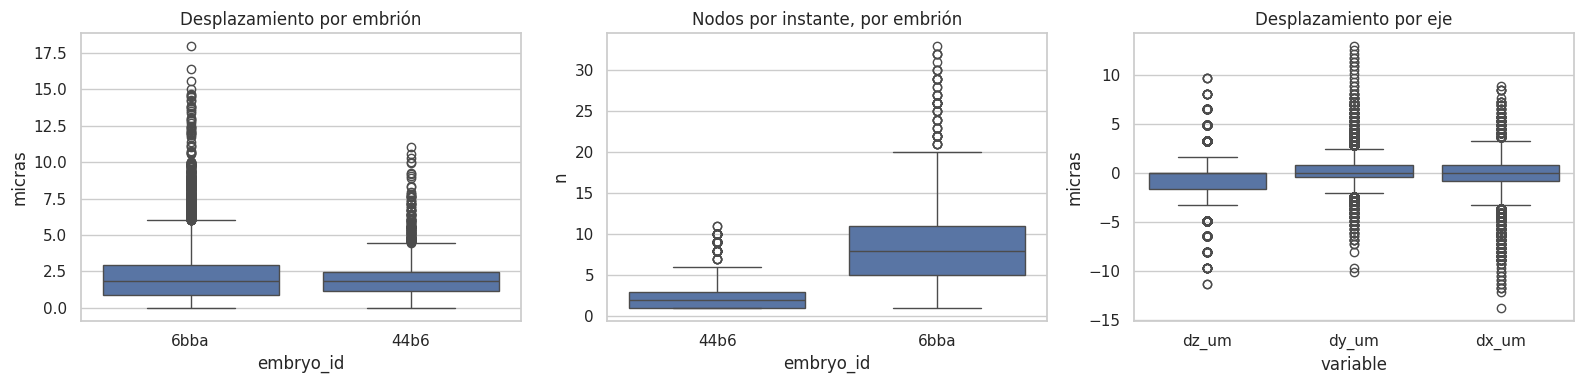

In [65]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df_edges[df_edges.dt == 1], x="embryo_id", y="dist_um", ax=ax[0])
ax[0].set_title("Desplazamiento por embrión"); ax[0].set_ylabel("micras")

sns.boxplot(data=nodos_t.merge(df_samples[["sample", "embryo_id"]], on="sample"),
            x="embryo_id", y="n", ax=ax[1])
ax[1].set_title("Nodos por instante, por embrión")

sns.boxplot(data=df_edges[df_edges.dt == 1].melt(value_vars=["dz_um", "dy_um", "dx_um"]),
            x="variable", y="value", ax=ax[2])
ax[2].set_title("Desplazamiento por eje"); ax[2].set_ylabel("micras")

plt.tight_layout(); plt.show()

### 5.c Cruces entre variables

Aquí se buscan las relaciones que explican el problema: cómo evoluciona la densidad de anotación en el
tiempo, si el movimiento celular depende del instante o de la profundidad, y qué tan correlacionadas están
las variables del grafo.

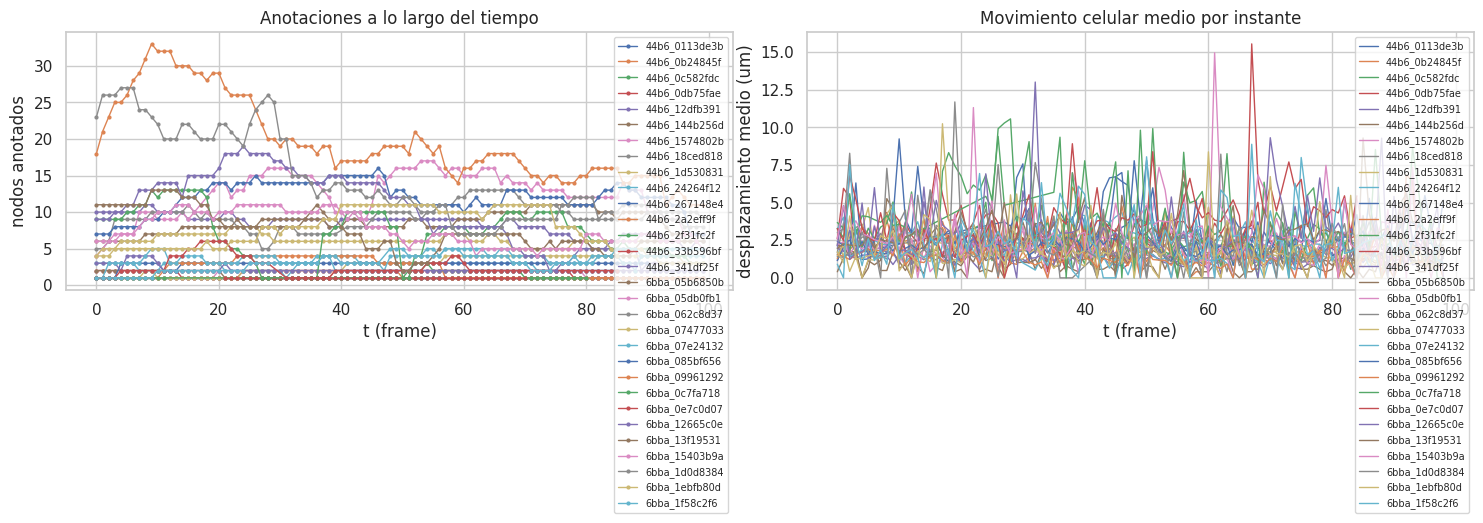

In [66]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

for s, g in nodos_t.groupby("sample"):
    ax[0].plot(g["t"], g["n"], marker="o", ms=2, lw=1, label=s[:18])
ax[0].set_xlabel("t (frame)"); ax[0].set_ylabel("nodos anotados")
ax[0].set_title("Anotaciones a lo largo del tiempo"); ax[0].legend(fontsize=7)

mov = df_edges[df_edges.dt == 1].groupby(["sample", "t_origen"])["dist_um"].mean().reset_index()
for s, g in mov.groupby("sample"):
    ax[1].plot(g["t_origen"], g["dist_um"], lw=1, label=s[:18])
ax[1].set_xlabel("t (frame)"); ax[1].set_ylabel("desplazamiento medio (um)")
ax[1].set_title("Movimiento celular medio por instante"); ax[1].legend(fontsize=7)

plt.tight_layout(); plt.show()

In [67]:
print("dt:", df_edges["dt"].value_counts(dropna=False).head(10).to_dict())
print("dt nulos:", df_edges["dt"].isna().sum(), "de", len(df_edges))
print("\nNaN en propiedades de nodos:")
print(df_nodes[["t", "z", "y", "x"]].isna().sum().to_dict())
print("\nMuestras con t nulo:")
print(df_nodes[df_nodes["t"].isna()]["sample"].value_counts().to_dict())

dt: {1.0: 15369}
dt nulos: 0 de 15369

NaN en propiedades de nodos:
{'t': 0, 'z': 0, 'y': 0, 'x': 0}

Muestras con t nulo:
{}


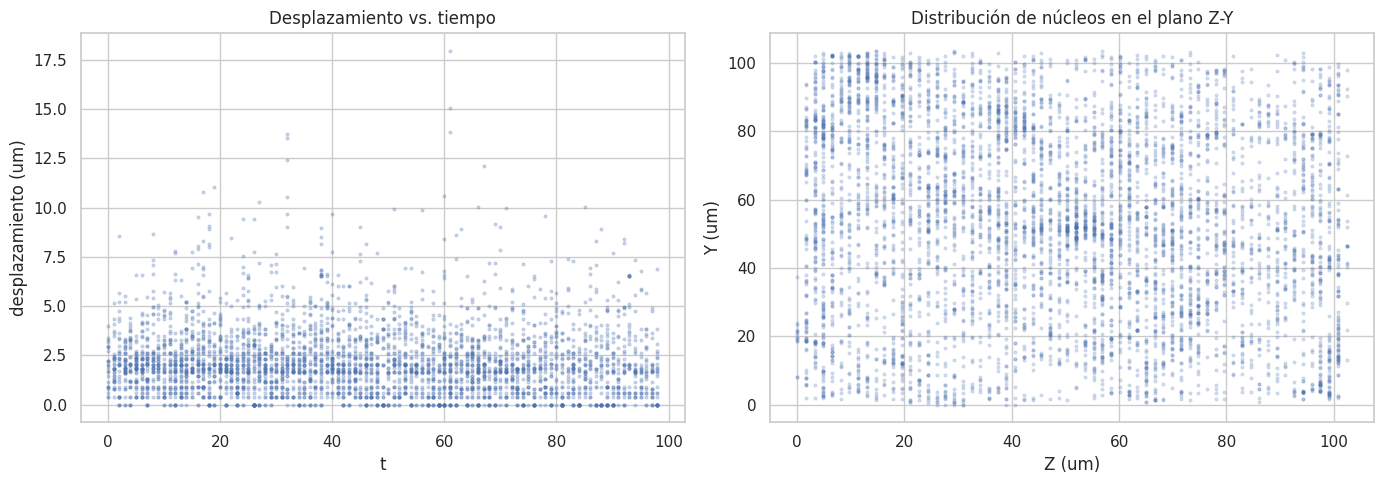

In [68]:
# Subconjunto de aristas consecutivas, con respaldo si el filtro deja poco
E1 = df_edges[df_edges["dt"] == 1]
if len(E1) == 0:
    print(f"AVISO: ninguna arista tiene dt == 1 (dt observados: "
          f"{df_edges['dt'].dropna().unique()[:5]}). Se usan todas las aristas.")
    E1 = df_edges.dropna(subset=["dist_um"])

def submuestra(df, n):
    return df.sample(min(n, len(df)), random_state=0) if len(df) else df

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sub = submuestra(E1, 4000)
ax[0].scatter(sub["t_origen"], sub["dist_um"], s=4, alpha=.25)
ax[0].set_xlabel("t"); ax[0].set_ylabel("desplazamiento (um)")
ax[0].set_title("Desplazamiento vs. tiempo")

nodos_z = submuestra(df_nodes, 6000)
ax[1].scatter(nodos_z["z_um"], nodos_z["y_um"], s=4, alpha=.2)
ax[1].set_xlabel("Z (um)"); ax[1].set_ylabel("Y (um)")
ax[1].set_title("Distribución de núcleos en el plano Z-Y")

plt.tight_layout(); plt.show()

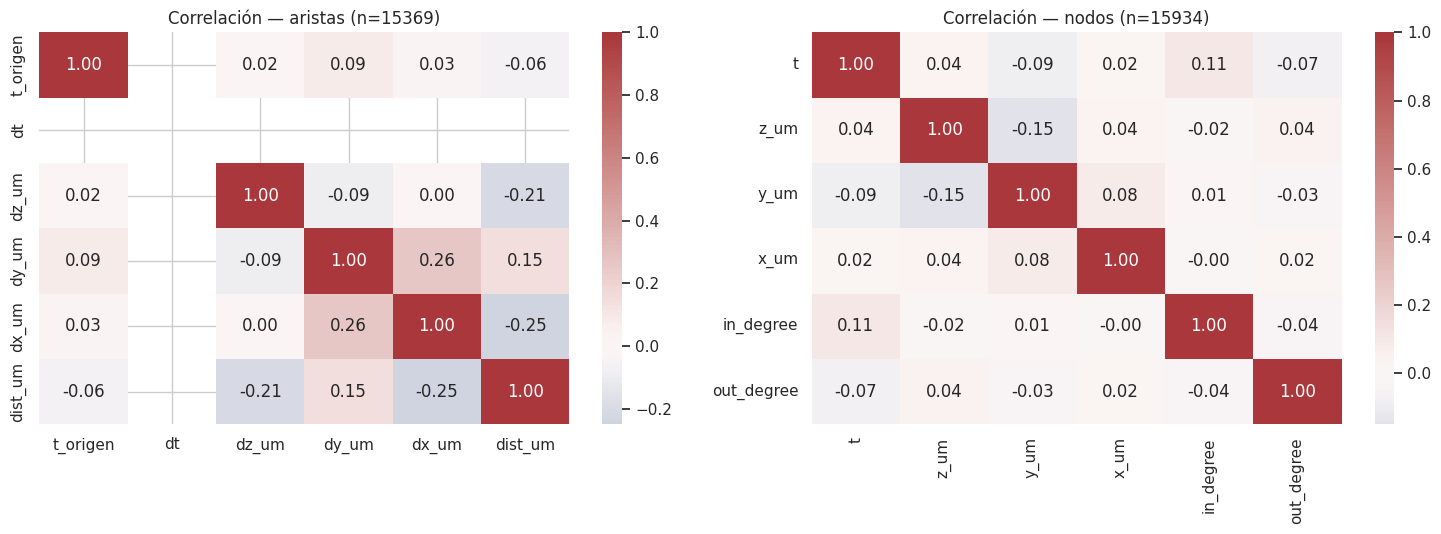

Nota: df_samples tiene solo 30 filas; sus correlaciones se reportan de forma descriptiva y no se interpretan como evidencia.


In [69]:
# Correlaciones. OJO: a nivel de muestra solo hay pocas filas, así que la matriz
# informativa es la de nivel arista/nodo, con miles de observaciones.
num_edges = df_edges[["t_origen", "dt", "dz_um", "dy_um", "dx_um", "dist_um"]]
num_nodes = df_nodes[["t", "z_um", "y_um", "x_um", "in_degree", "out_degree"]]

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(num_edges.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax[0])
ax[0].set_title(f"Correlación — aristas (n={len(df_edges)})")
sns.heatmap(num_nodes.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax[1])
ax[1].set_title(f"Correlación — nodos (n={len(df_nodes)})")
plt.tight_layout(); plt.show()

print(f"Nota: df_samples tiene solo {len(df_samples)} filas; sus correlaciones se reportan "
      "de forma descriptiva y no se interpretan como evidencia.")

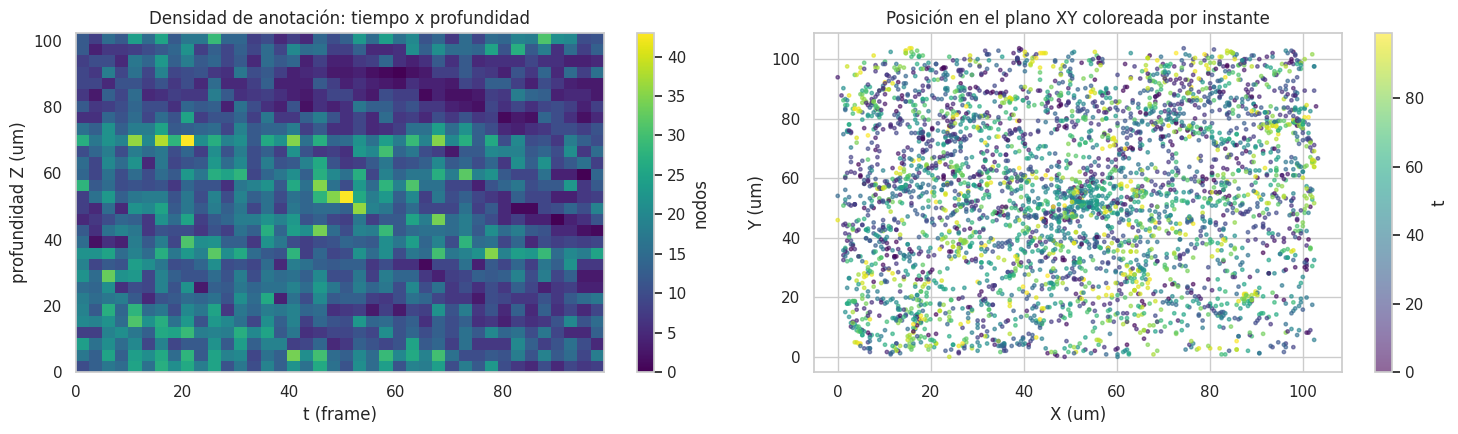

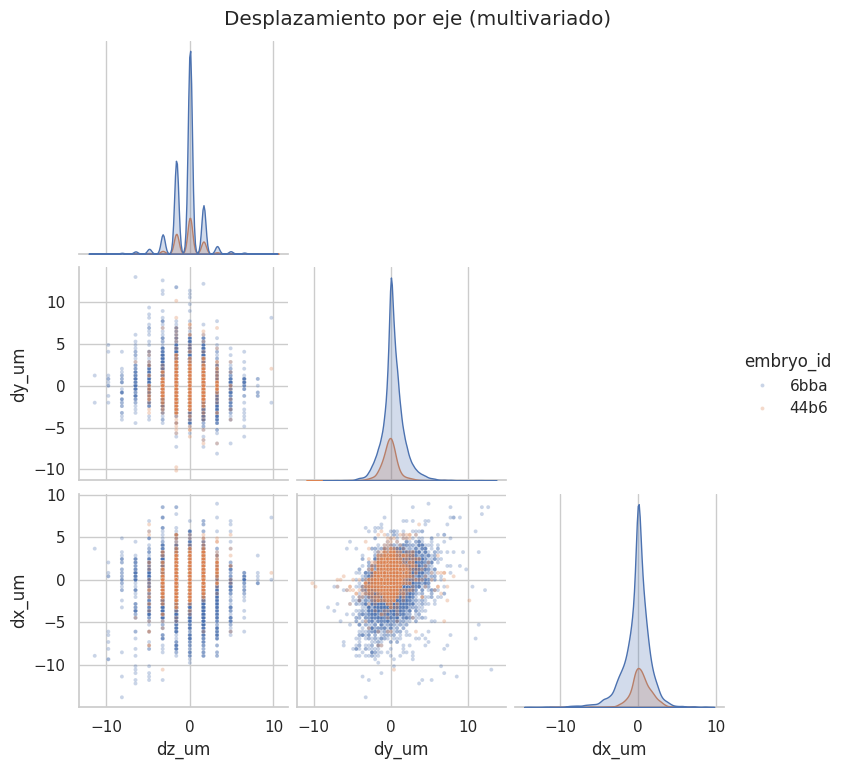

In [70]:
# --- Vistas multivariadas ----------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

h = ax[0].hist2d(df_nodes["t"], df_nodes["z_um"], bins=[40, 30], cmap="viridis")
plt.colorbar(h[3], ax=ax[0], label="nodos")
ax[0].set_xlabel("t (frame)"); ax[0].set_ylabel("profundidad Z (um)")
ax[0].set_title("Densidad de anotación: tiempo x profundidad")

sub = df_nodes.sample(min(4000, len(df_nodes)), random_state=0)
sc = ax[1].scatter(sub["x_um"], sub["y_um"], c=sub["t"], s=6, alpha=.6, cmap="viridis")
plt.colorbar(sc, ax=ax[1], label="t")
ax[1].set_xlabel("X (um)"); ax[1].set_ylabel("Y (um)")
ax[1].set_title("Posición en el plano XY coloreada por instante")
plt.tight_layout(); plt.show()

# Relación conjunta de las tres componentes del desplazamiento
g = sns.pairplot(df_edges[df_edges.dt == 1][["dz_um", "dy_um", "dx_um", "embryo_id"]],
                 hue="embryo_id", corner=True, plot_kws=dict(s=8, alpha=.3))
g.figure.suptitle("Desplazamiento por eje (multivariado)", y=1.02)
plt.show()

In [71]:
e1 = df_edges[df_edges.dt == 1]
q1, q3 = e1["dist_um"].quantile([.25, .75])
lim_sup = q3 + 1.5 * (q3 - q1)
out = e1[e1.dist_um > lim_sup]

print(f"Límite de Tukey: {lim_sup:.2f} um")
print(f"Atípicos: {len(out)} de {len(e1)} ({100*len(out)/len(e1):.2f}%)")
print(f"Máximo observado: {e1.dist_um.max():.2f} um")
print("\nAtípicos por embrión (%):")
print((out.groupby("embryo_id").size() / e1.groupby("embryo_id").size() * 100).round(2).to_string())
print("\nAtípicos por tipo de origen: divisiones vs. no divisiones")
print(pd.crosstab(e1.out_degree_origen >= 2, e1.dist_um > lim_sup, normalize="index").round(3))

Límite de Tukey: 5.82 um
Atípicos: 611 de 15369 (3.98%)
Máximo observado: 17.97 um

Atípicos por embrión (%):
embryo_id
44b6    1.83
6bba    4.45

Atípicos por tipo de origen: divisiones vs. no divisiones
dist_um            False  True 
out_degree_origen              
False              0.961  0.039
True               0.575  0.425


Divisiones: 20 de 15934 nodos (0.126%)

Por muestra:
       sample  n_nodos  n_divisiones  tasa_division
6bba_05b6850b      861             0         0.0000
6bba_05db0fb1     1229             3         0.0024
6bba_062c8d37      930             1         0.0011
6bba_07477033      613             0         0.0000
6bba_07e24132      359             2         0.0056
6bba_085bf656     1198             1         0.0008
6bba_09961292     1950             4         0.0021
6bba_0c7fa718      704             0         0.0000
6bba_0e7c0d07      209             1         0.0048
6bba_12665c0e     1036             3         0.0029
6bba_13f19531      737             0         0.0000
6bba_15403b9a      758             0         0.0000
6bba_1d0d8384     1438             1         0.0007
6bba_1ebfb80d      745             0         0.0000
6bba_1f58c2f6      317             0         0.0000
44b6_0113de3b       52             0         0.0000
44b6_0b24845f       51             0         0.0000
44b6_0c582f

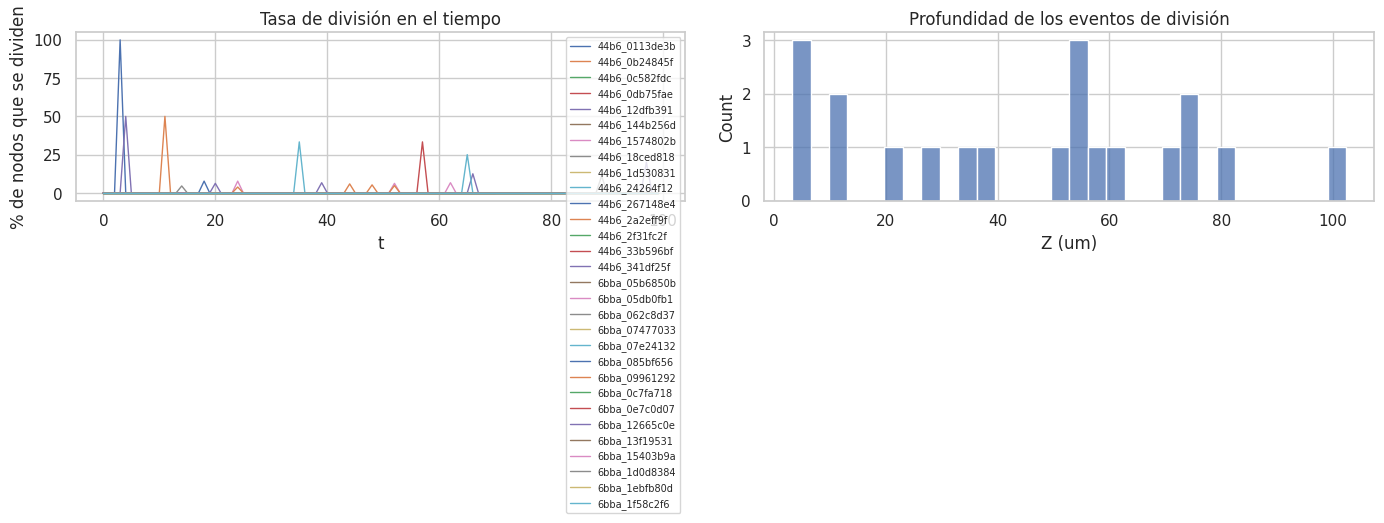

In [72]:
div = df_nodes[df_nodes.es_division]
print(f"Divisiones: {len(div)} de {len(df_nodes)} nodos ({100*len(div)/len(df_nodes):.3f}%)")
print("\nPor muestra:")
print(df_samples[["sample", "n_nodos", "n_divisiones", "tasa_division"]].round(4).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
tasa = (df_nodes.groupby(["sample", "t"])["es_division"].mean() * 100).reset_index()
for s, g in tasa.groupby("sample"):
    ax[0].plot(g["t"], g["es_division"], lw=1, label=s[:18])
ax[0].set_xlabel("t"); ax[0].set_ylabel("% de nodos que se dividen")
ax[0].set_title("Tasa de división en el tiempo"); ax[0].legend(fontsize=7)

if len(div):
    sns.histplot(div["z_um"], bins=30, ax=ax[1])
    ax[1].set_title("Profundidad de los eventos de división"); ax[1].set_xlabel("Z (um)")
plt.tight_layout(); plt.show()

Linajes: 565


,count,mean,std,min,25%,50%,75%,max
n_nodos,565.0,28.20,23.50,2.0,12.0,20.0,38.0,111.0
duracion,565.0,27.92,23.14,2.0,12.0,20.0,37.0,100.0
n_divisiones,565.0,0.04,0.18,0.0,0.0,0.0,0.0,1.0


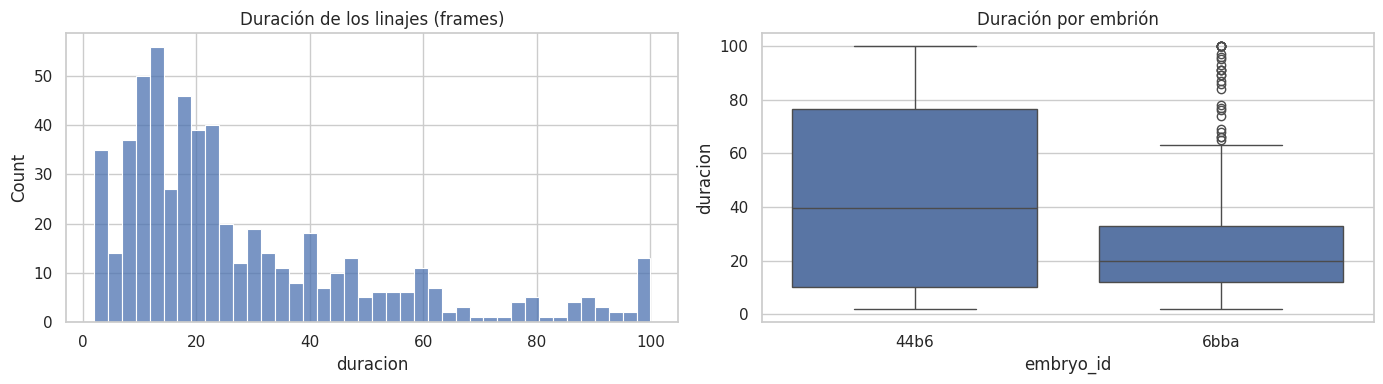

In [73]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

filas = []
for s, g in df_nodes.groupby("sample"):
    g = g.reset_index(drop=True)
    pos = {int(v): i for i, v in enumerate(g.node_id)}
    _, ids, _, edges = read_geff(s)
    src = np.array([pos[int(a)] for a, b in edges if int(a) in pos and int(b) in pos], int)
    dst = np.array([pos[int(b)] for a, b in edges if int(a) in pos and int(b) in pos], int)
    m = coo_matrix((np.ones(len(src)), (src, dst)), shape=(len(g), len(g)))
    n_comp, etiqueta = connected_components(m, directed=False)
    g["linaje"] = etiqueta
    filas.append(g.groupby("linaje").agg(sample=("sample", "first"),
                                         embryo_id=("embryo_id", "first"),
                                         n_nodos=("t", "size"),
                                         duracion=("t", lambda x: x.max() - x.min() + 1),
                                         n_divisiones=("es_division", "sum")).reset_index())

df_linajes = pd.concat(filas, ignore_index=True)
print(f"Linajes: {len(df_linajes)}")
display(df_linajes[["n_nodos", "duracion", "n_divisiones"]].describe().T.round(2))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_linajes["duracion"], bins=40, ax=ax[0])
ax[0].set_title("Duración de los linajes (frames)")
sns.boxplot(data=df_linajes, x="embryo_id", y="duracion", ax=ax[1])
ax[1].set_title("Duración por embrión")
plt.tight_layout(); plt.show()

In [74]:
# --- Selección del nivel de pirámide y del instante a descargar -------------
VIS_SAMPLE = df_samples.sort_values("n_nodos", ascending=False).iloc[0]["sample"]
VIS_T = int(df_nodes[df_nodes["sample"] == VIS_SAMPLE]["t"].value_counts().idxmax())

niveles = image_levels(VIS_SAMPLE)
assert niveles, "No hay metadatos de imagen descargados para esta muestra."
ndim = len(niveles[sorted(niveles)[0]]["shape"])
if ndim != 4:
    print(f"AVISO: el arreglo tiene {ndim} dimensiones, no 4 (T,Z,Y,X). Revisa chunk_paths.")
itemsize = np.dtype(niveles["0"]["dtype"]).itemsize if "0" in niveles else 2

info = {}
for name, m in niveles.items():
    mb = np.prod(m["shape"][1:]) * itemsize / 1e6
    info[name] = mb
print("Tamaño de un instante por nivel (MB, sin comprimir):")
for k, v in sorted(info.items()):
    print(f"  nivel {k}: {niveles[k]['shape']} -> {v:.1f} MB")

candidatos = {k: v for k, v in info.items() if v <= IMAGE_BUDGET_MB}
VIS_LEVEL = max(candidatos, key=lambda k: info[k]) if candidatos else min(info, key=lambda k: info[k])
meta = niveles[VIS_LEVEL]
print(f"\nMuestra: {VIS_SAMPLE} | instante t={VIS_T} | nivel elegido: {VIS_LEVEL} "
      f"({info[VIS_LEVEL]:.1f} MB, shape {meta['shape']})")

Tamaño de un instante por nivel (MB, sin comprimir):
  nivel 0: (100, 64, 256, 256) -> 8.4 MB

Muestra: 6bba_09961292 | instante t=9 | nivel elegido: 0 (8.4 MB, shape (100, 64, 256, 256))


In [75]:
# --- Descarga de los chunks que cubren ese instante --------------------------
def chunk_paths(meta, t_index, y_rango=None, x_rango=None):
    """Rutas relativas de los chunks que cubren un instante (y opcionalmente un recorte)."""
    shape, ch = meta["shape"], meta["chunks"]
    enc = meta["encoding"]
    sep = enc.get("configuration", {}).get("separator", "." if enc.get("name") == "v2" else "/")
    prefijo = [] if enc.get("name") == "v2" else ["c"]

    def rango(dim, lim):
        lo, hi = (0, shape[dim]) if lim is None else lim
        return range(lo // ch[dim], (hi - 1) // ch[dim] + 1)

    rutas = []
    for cz in rango(1, None):
        for cy in rango(2, y_rango):
            for cx in rango(3, x_rango):
                idx = (t_index // ch[0], cz, cy, cx)
                rutas.append(sep.join(prefijo + [str(i) for i in idx]))
    return rutas


# Si ni el nivel más pequeño cabe, se recorta una ventana centrada en Y/X.
crop_y = crop_x = None
if info[VIS_LEVEL] > IMAGE_BUDGET_MB:
    shape, ch = meta["shape"], meta["chunks"]
    mb_chunk = np.prod(ch[1:]) * itemsize / 1e6
    n_chunks_z = int(np.ceil(shape[1] / ch[1]))
    permitidos = max(1, int(IMAGE_BUDGET_MB / (mb_chunk * n_chunks_z)))
    lado = max(1, int(np.sqrt(permitidos)))
    cy0 = max(0, (shape[2] // ch[2]) // 2 - lado // 2)
    cx0 = max(0, (shape[3] // ch[3]) // 2 - lado // 2)
    crop_y = (cy0 * ch[2], min(shape[2], (cy0 + lado) * ch[2]))
    crop_x = (cx0 * ch[3], min(shape[3], (cx0 + lado) * ch[3]))
    print(f"El nivel excede el presupuesto: se recorta Y{crop_y} X{crop_x}")

rutas = chunk_paths(meta, VIS_T, crop_y, crop_x)
archivos = [f"train/{VIS_SAMPLE}.zarr/{VIS_LEVEL}/{r}" for r in rutas]
print(f"Chunks a descargar: {len(archivos)}")
download_many(archivos, desc="Chunks de imagen")

!du -sh {DATA_DIR}

Chunks a descargar: 1


Chunks de imagen:   0%|          | 0/1 [00:00<?, ?it/s]

9.6M	/content/data


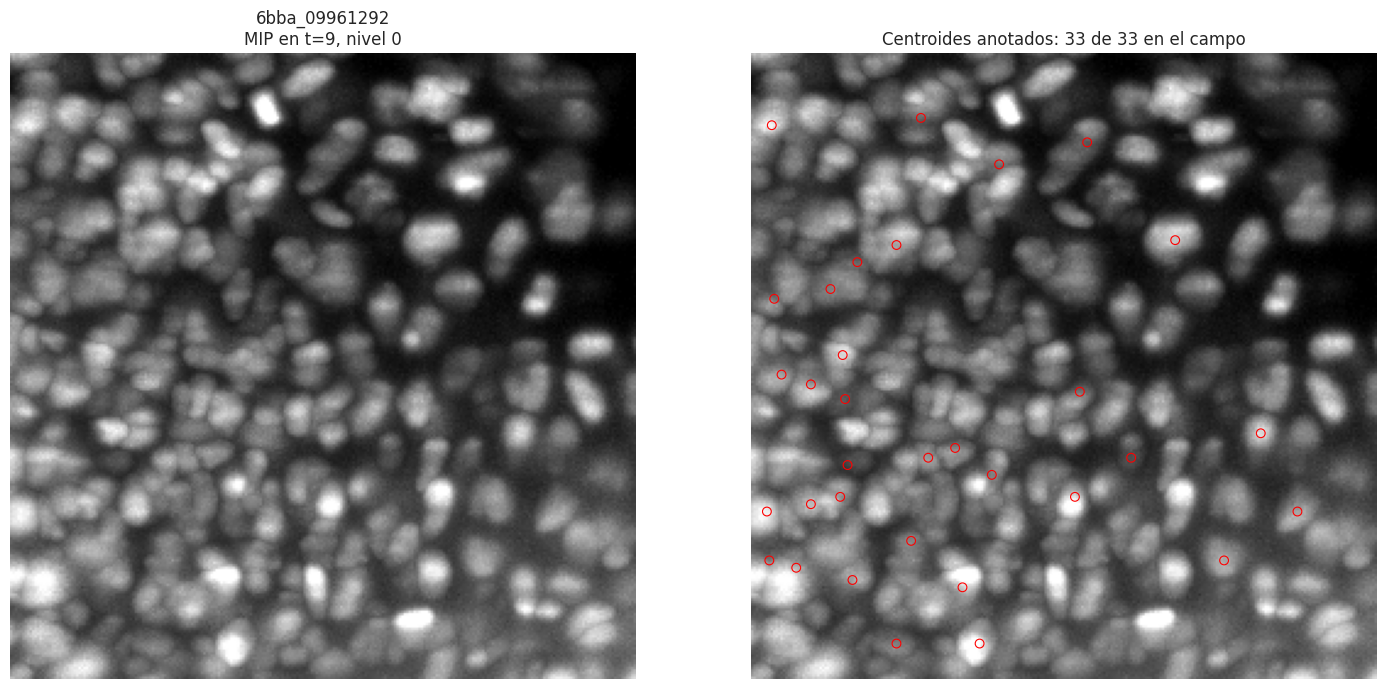

In [76]:
# --- Proyección de máxima intensidad con los centroides anotados encima ------
arr = zarr.open(str(TRAIN_DIR / f"{VIS_SAMPLE}.zarr" / VIS_LEVEL), mode="r")
y0, y1 = crop_y if crop_y else (0, meta["shape"][2])
x0, x1 = crop_x if crop_x else (0, meta["shape"][3])
vol = np.asarray(arr[VIS_T, :, y0:y1, x0:x1])
mip = vol.max(axis=0)

# Los centroides están en píxeles del nivel 0: se reescalan al nivel descargado.
shape0 = niveles["0"]["shape"] if "0" in niveles else meta["shape"]
fy, fx = shape0[2] / meta["shape"][2], shape0[3] / meta["shape"][3]

n = df_nodes[(df_nodes["sample"] == VIS_SAMPLE) & (df_nodes["t"] == VIS_T)]
py, px = n["y"] / fy - y0, n["x"] / fx - x0
dentro = (py >= 0) & (py < mip.shape[0]) & (px >= 0) & (px < mip.shape[1])

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(mip, cmap="gray", vmin=np.percentile(mip, 1), vmax=np.percentile(mip, 99.5))
ax[0].set_title(f"{VIS_SAMPLE}\nMIP en t={VIS_T}, nivel {VIS_LEVEL}"); ax[0].axis("off")

ax[1].imshow(mip, cmap="gray", vmin=np.percentile(mip, 1), vmax=np.percentile(mip, 99.5))
ax[1].scatter(px[dentro], py[dentro], s=40, facecolor="none", edgecolor="red", lw=.8)
ax[1].set_title(f"Centroides anotados: {int(dentro.sum())} de {len(n)} en el campo")
ax[1].axis("off")
plt.tight_layout(); plt.show()

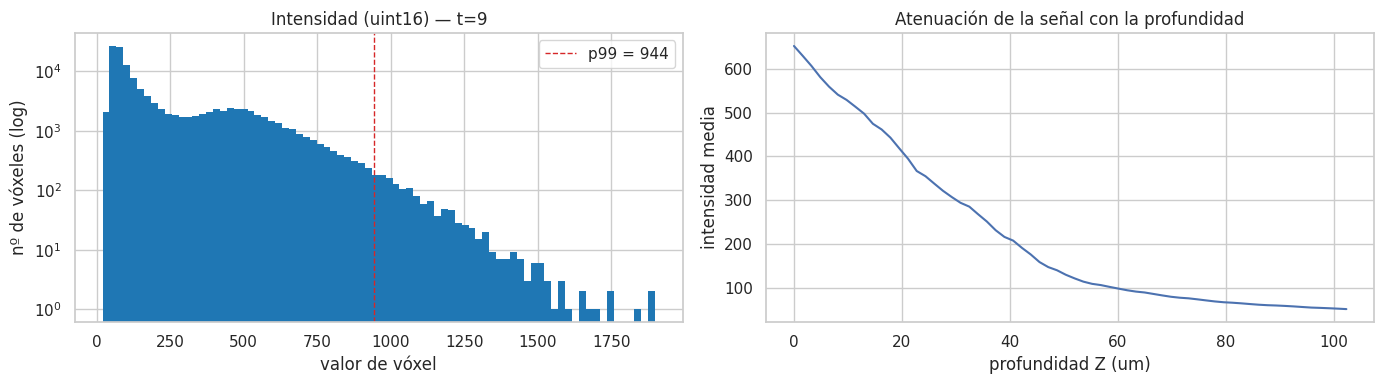

Rango: 15 – 2052 (3.1% del rango del uint16)
Mediana (fondo): 110 | p99: 944 | p99.9: 1262
Vóxeles por encima del p99: 1.00%
Atenuación: la intensidad media cae de 652 en la superficie a 52 en el fondo (92% de pérdida)


In [80]:
# --- Distribución de intensidades -------------------------------------------
muestra_px = np.asarray(vol[::2, ::4, ::4]).ravel()
p99 = np.percentile(muestra_px, 99)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(muestra_px, bins=80, log=True, color="tab:blue", edgecolor="none")
ax[0].axvline(p99, ls="--", lw=1, color="tab:red", label=f"p99 = {p99:.0f}")
ax[0].set_title(f"Intensidad ({vol.dtype}) — t={VIS_T}")
ax[0].set_xlabel("valor de vóxel"); ax[0].set_ylabel("nº de vóxeles (log)")
ax[0].legend()

perfil = vol.reshape(vol.shape[0], -1).mean(axis=1)
ax[1].plot(np.arange(len(perfil)) * VOXEL_UM[0] * (shape0[1] / meta["shape"][1]), perfil)
ax[1].set_xlabel("profundidad Z (um)"); ax[1].set_ylabel("intensidad media")
ax[1].set_title("Atenuación de la señal con la profundidad")

plt.tight_layout(); plt.show()

print(f"Rango: {vol.min()} – {vol.max()} ({(vol.max()/65535)*100:.1f}% del rango del uint16)")
print(f"Mediana (fondo): {np.median(muestra_px):.0f} | p99: {p99:.0f} | "
      f"p99.9: {np.percentile(muestra_px, 99.9):.0f}")
print(f"Vóxeles por encima del p99: {(muestra_px > p99).mean()*100:.2f}%")
print(f"Atenuación: la intensidad media cae de {perfil[0]:.0f} en la superficie "
      f"a {perfil[-1]:.0f} en el fondo ({(1-perfil[-1]/perfil[0])*100:.0f}% de pérdida)")

In [78]:
# Resumen numérico listo para copiar al informe
e1 = df_edges[df_edges.dt == 1]
nodos_por_t = df_nodes.groupby(["sample", "t"]).size()
dims = tuple(int(v) for v in df_samples.iloc[0][["T", "Z", "Y", "X"]])
dtipo = df_samples["dtype"].iloc[0]
tasa_div = df_nodes["es_division"].mean()
dens_glob = df_samples.n_nodos.sum() / df_samples.estimated_number_of_nodes.sum() * 100

por_embrion = (df_nodes.groupby("embryo_id").size().rename("nodos").to_frame()
               .join(e1.groupby("embryo_id")["dist_um"].median().rename("desplaz_mediana_um"))
               .round(2).to_string())

print(f"""
DATOS ANALIZADOS
  Muestras: {len(df_samples)} de {df_samples.embryo_id.nunique()} embriones distintos
  Dimensiones (T, Z, Y, X): {dims} | dtype: {dtipo}
  Escala del vóxel: {tuple(VOXEL_UM.tolist())} um -> anisotropía {VOXEL_UM[0]/VOXEL_UM[1]:.0f}x en Z
  Nodos: {len(df_nodes):,} | Aristas: {len(df_edges):,} | Linajes: {len(df_linajes):,}

DENSIDAD Y ESPARCIDAD DE LA ANOTACIÓN
  Nodos por instante: mediana {nodos_por_t.median():.0f} (rango {nodos_por_t.min()}-{nodos_por_t.max()})
  Cobertura temporal media: {df_samples.cobertura_temporal.mean()*100:.1f}% de los frames del video
  Densidad de anotación global: {dens_glob:.2f}% de las células estimadas
    (por muestra: {df_samples.densidad_anotacion.min():.2f}% - {df_samples.densidad_anotacion.max():.2f}%)
  Aristas por nodo: {df_samples.aristas_por_nodo.mean():.2f}

DINÁMICA CELULAR (enlaces con dt=1)
  Desplazamiento: mediana {e1.dist_um.median():.2f} um | p95 {e1.dist_um.quantile(.95):.2f} um
                  p99 {e1.dist_um.quantile(.99):.2f} um | máximo {e1.dist_um.max():.2f} um
  Duración de linajes: mediana {df_linajes.duracion.median():.0f} frames | máx {df_linajes.duracion.max():.0f}

DIVISIONES
  {int(df_nodes.es_division.sum()):,} eventos = {tasa_div*100:.3f}% de los nodos
  Desbalance aproximado 1:{int(1/max(tasa_div, 1e-9)):,}

VARIABILIDAD ENTRE EMBRIONES
{por_embrion}
""")


DATOS ANALIZADOS
  Muestras: 30 de 2 embriones distintos
  Dimensiones (T, Z, Y, X): (100, 64, 256, 256) | dtype: uint16
  Escala del vóxel: (1.625, 0.40625, 0.40625) um -> anisotropía 4x en Z
  Nodos: 15,934 | Aristas: 15,369 | Linajes: 565

DENSIDAD Y ESPARCIDAD DE LA ANOTACIÓN
  Nodos por instante: mediana 4 (rango 1-33)
  Cobertura temporal media: 91.0% de los frames del video
  Densidad de anotación global: 2.05% de las células estimadas
    (por muestra: 0.13% - 15.42%)
  Aristas por nodo: 0.97

DINÁMICA CELULAR (enlaces con dt=1)
  Desplazamiento: mediana 1.86 um | p95 5.40 um
                  p99 8.35 um | máximo 17.97 um
  Duración de linajes: mediana 20 frames | máx 100

DIVISIONES
  20 eventos = 0.126% de los nodos
  Desbalance aproximado 1:796

VARIABILIDAD ENTRE EMBRIONES
           nodos  desplaz_mediana_um
embryo_id                           
44b6        2850                1.82
6bba       13084                1.86

